   fixed acidity  volatile acidity  citric acid  residual sugar  chlorides  \
0            7.4              0.70         0.00             1.9      0.076   
1            7.8              0.88         0.00             2.6      0.098   
2            7.8              0.76         0.04             2.3      0.092   
3           11.2              0.28         0.56             1.9      0.075   
4            7.4              0.70         0.00             1.9      0.076   

   free sulfur dioxide  total sulfur dioxide  density    pH  sulphates  \
0                 11.0                  34.0   0.9978  3.51       0.56   
1                 25.0                  67.0   0.9968  3.20       0.68   
2                 15.0                  54.0   0.9970  3.26       0.65   
3                 17.0                  60.0   0.9980  3.16       0.58   
4                 11.0                  34.0   0.9978  3.51       0.56   

   alcohol  quality  Id  
0      9.4        5   0  
1      9.8        5   1  
2      9

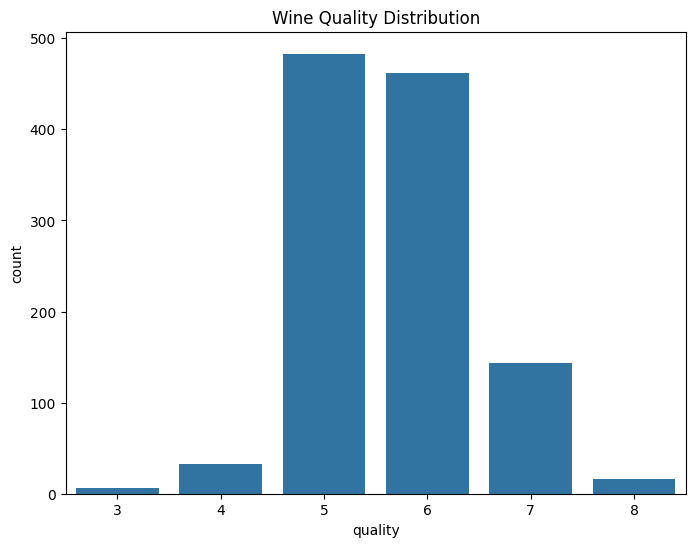

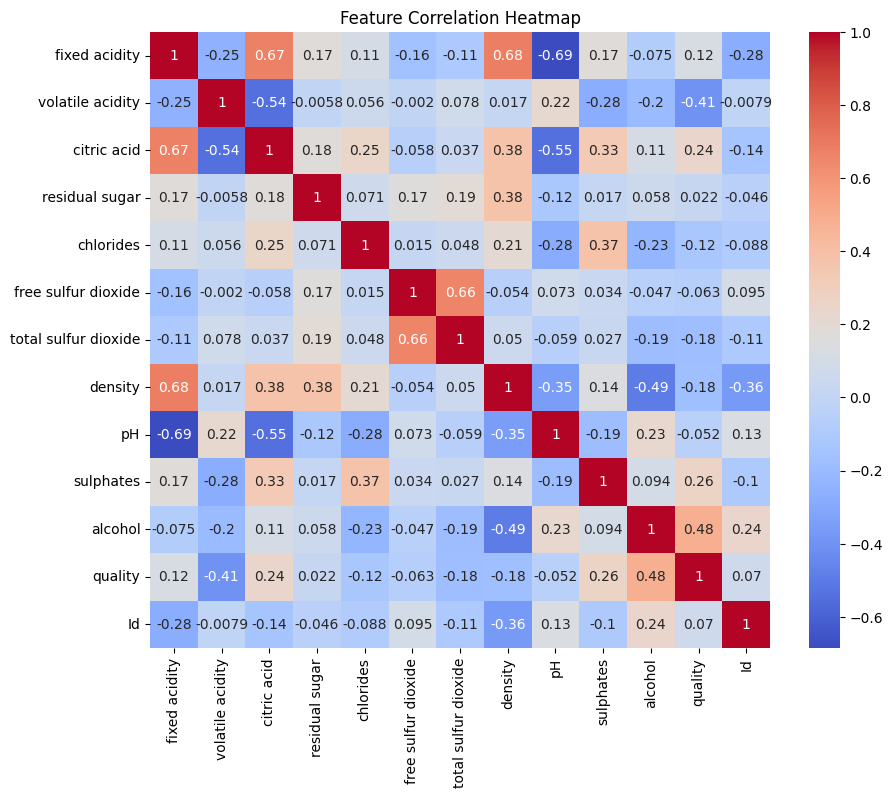

Random Forest Accuracy: 0.9213973799126638
              precision    recall  f1-score   support

           0       0.94      0.97      0.96       201
           1       0.73      0.57      0.64        28

    accuracy                           0.92       229
   macro avg       0.83      0.77      0.80       229
weighted avg       0.92      0.92      0.92       229

SGD Classifier Accuracy: 0.8777292576419214
              precision    recall  f1-score   support

           0       0.91      0.96      0.93       201
           1       0.50      0.29      0.36        28

    accuracy                           0.88       229
   macro avg       0.70      0.62      0.65       229
weighted avg       0.86      0.88      0.86       229

SVC Accuracy: 0.8908296943231441
              precision    recall  f1-score   support

           0       0.91      0.98      0.94       201
           1       0.62      0.29      0.39        28

    accuracy                           0.89       229
   macro

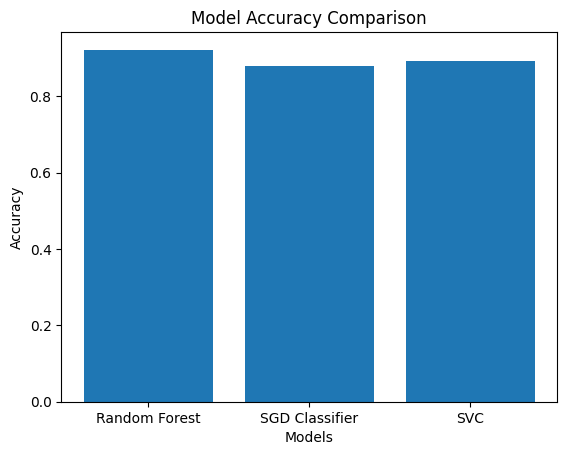

In [1]:
# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.svm import SVC

# Step 2: Load Dataset
data = pd.read_csv("WineQT.csv")

# Display first rows
print(data.head())

# Step 3: Explore Dataset
print(data.info())
print(data.describe())

# Step 4: Check Missing Values
print(data.isnull().sum())

# Step 5: Data Visualization
plt.figure(figsize=(8,6))
sns.countplot(x='quality', data=data)
plt.title("Wine Quality Distribution")
plt.show()

# Correlation heatmap
plt.figure(figsize=(10,8))
sns.heatmap(data.corr(), annot=True, cmap="coolwarm")
plt.title("Feature Correlation Heatmap")
plt.show()

# Step 6: Feature and Target Selection
X = data.drop(["quality","Id"], axis=1)
y = data["quality"]

# Convert quality into classification (good or bad wine)
y = y.apply(lambda x: 1 if x >= 7 else 0)

# Step 7: Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Step 8: Feature Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# -------------------------------
# Model 1: Random Forest
# -------------------------------
rf = RandomForestClassifier()
rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

print("Random Forest Accuracy:", accuracy_score(y_test, rf_pred))
print(classification_report(y_test, rf_pred))

# -------------------------------
# Model 2: SGD Classifier
# -------------------------------
sgd = SGDClassifier()
sgd.fit(X_train, y_train)

sgd_pred = sgd.predict(X_test)

print("SGD Classifier Accuracy:", accuracy_score(y_test, sgd_pred))
print(classification_report(y_test, sgd_pred))

# -------------------------------
# Model 3: Support Vector Classifier
# -------------------------------
svc = SVC()
svc.fit(X_train, y_train)

svc_pred = svc.predict(X_test)

print("SVC Accuracy:", accuracy_score(y_test, svc_pred))
print(classification_report(y_test, svc_pred))

# Step 9: Compare Model Accuracy
models = ["Random Forest", "SGD Classifier", "SVC"]
accuracy = [
    accuracy_score(y_test, rf_pred),
    accuracy_score(y_test, sgd_pred),
    accuracy_score(y_test, svc_pred)
]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.show()